# Analyse de Réseau et Co-occurrence des Tags de Gameplay

## Objectif
Après avoir structuré nos tags dans une taxonomie propre, nous allons analyser les corrélations entre les différentes dimensions (ex: quels genres sont les plus associés à quelles mécaniques ?).

Cette étape est cruciale pour :
1. **Identifier des patterns de design** : Groupements naturels de mécaniques.
2. **Détecter des niches** : Combinaisons de tags rares mais cohérentes.

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import networkx as nx

# Chargement de la base structurée
df = pd.read_csv('../data/Games_Gameplay_Taxonomy.csv')

# On se concentre sur les Genre et Mechanics pour la co-occurrence
print(f"Base chargée : {df.shape[0]} jeux.")

Base chargée : 100384 jeux.


## 1. Matrice de Co-occurrence Genre vs Mécaniques

Nous allons calculer combien de fois un Genre (ex: RPG) apparaît avec une Mécanique (ex: Crafting).

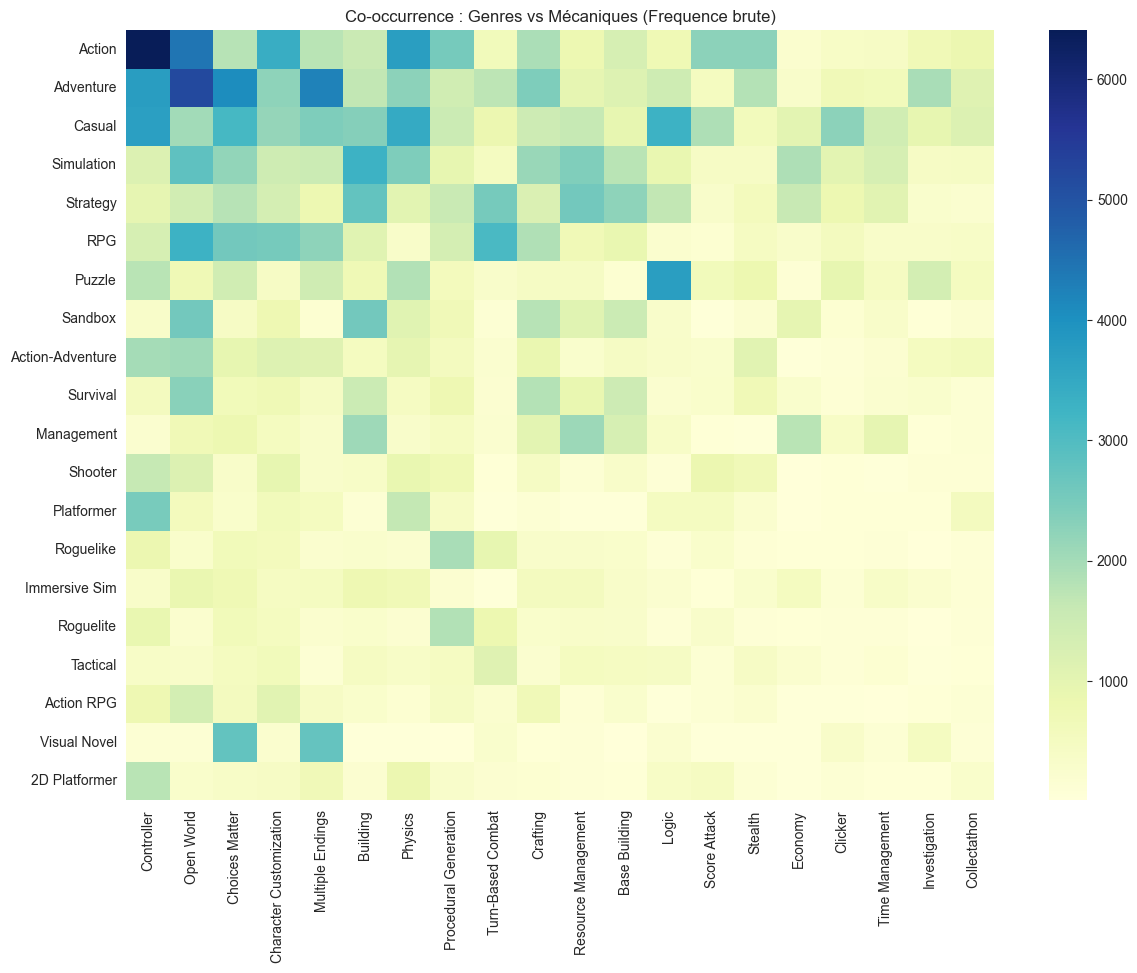

In [16]:
def get_cooccurrence_matrix(df, col1, col2):
    # Extraction des listes de tags
    s1 = df[col1].str.split(', ').fillna('').tolist()
    s2 = df[col2].str.split(', ').fillna('').tolist()
    
    # Liste de tous les tags uniques pour chaque colonne
    tags1 = sorted(list(set([t for sub in s1 for t in sub if t])))
    tags2 = sorted(list(set([t for sub in s2 for t in sub if t])))
    
    matrix = pd.DataFrame(0, index=tags1, columns=tags2)
    
    for i in range(len(s1)):
        for t1 in s1[i]:
            for t2 in s2[i]:
                if t1 and t2:
                    matrix.loc[t1, t2] += 1
    return matrix

cooc_matrix = get_cooccurrence_matrix(df, 'Genre', 'Mechanics')

# Visualisation par Heatmap (Top 20 genres / Top 20 mechanics)
top_genres = cooc_matrix.sum(axis=1).sort_values(ascending=False).head(20).index
top_mechanics = cooc_matrix.sum(axis=0).sort_values(ascending=False).head(20).index

plt.figure(figsize=(14, 10))
sns.heatmap(cooc_matrix.loc[top_genres, top_mechanics], annot=False, cmap="YlGnBu")
plt.title("Co-occurrence : Genres vs Mécaniques (Frequence brute)")
plt.show()

*Cette matrice de corrélation brute montre les associations les plus fréquentes, mais elle est biaisée par la popularité des tags. Par exemple, un genre très populaire comme "Action" apparaîtra souvent avec de nombreuses mécaniques simplement parce qu'il est présent dans beaucoup de jeux. C'est pourquoi nous allons normaliser cette matrice pour mieux comprendre les associations significatives.*

## 2. Analyse de Proximité (Lift/Normalisation)

La fréquence brute favorise les tags populaires. Nous utilisons le Lift pour voir quelles associations sont plus fréquentes que prévu par le simple hasard.

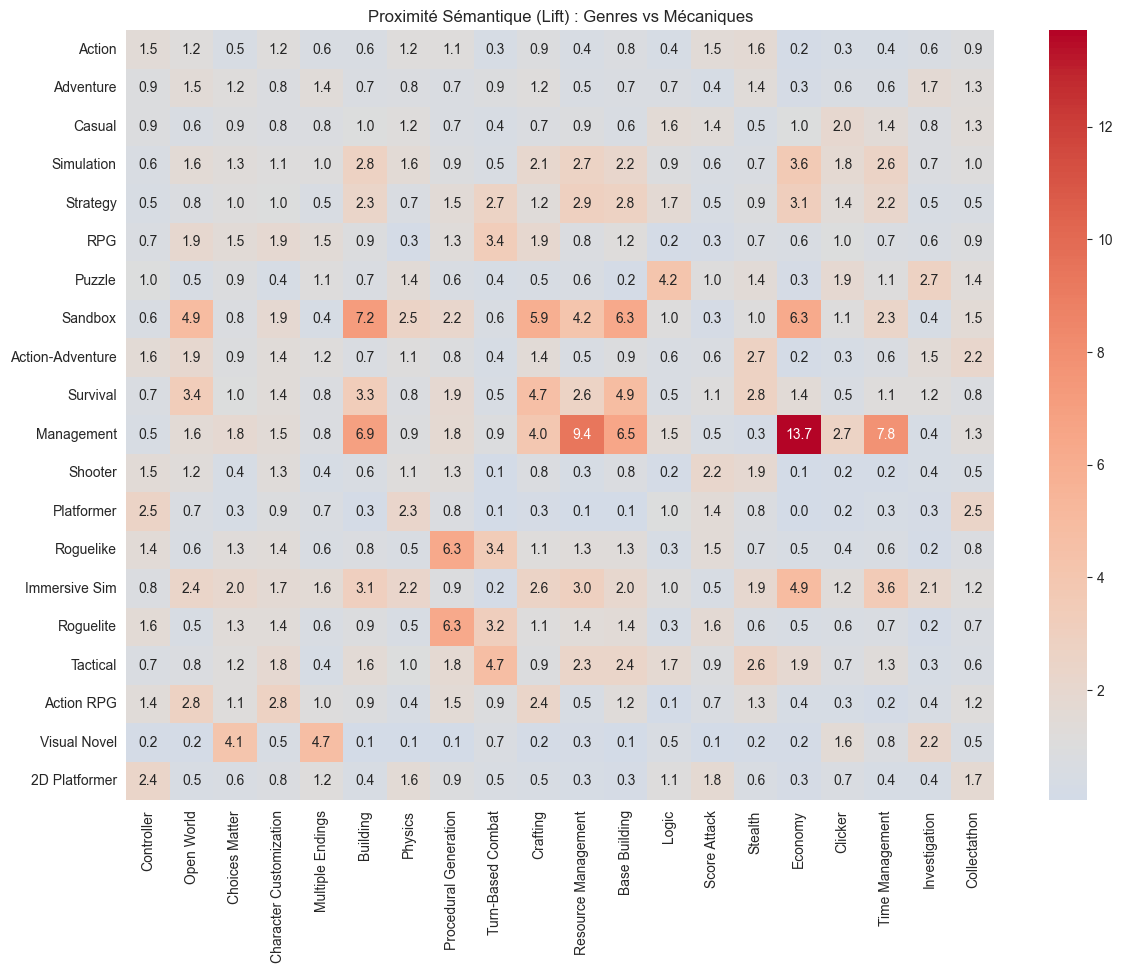

In [17]:
N = len(df)
genre_counts = df['Genre'].str.split(', ').explode().value_counts()
mech_counts = df['Mechanics'].str.split(', ').explode().value_counts()

lift_matrix = cooc_matrix.copy().astype(float)
for g in lift_matrix.index:
    for m in lift_matrix.columns:
        expected = (genre_counts[g] * mech_counts[m]) / N
        if expected > 0:
            lift_matrix.loc[g, m] = cooc_matrix.loc[g, m] / expected
        else:
            lift_matrix.loc[g, m] = 0

plt.figure(figsize=(14, 10))
sns.heatmap(lift_matrix.loc[top_genres, top_mechanics], annot=True, fmt=".1f", cmap="coolwarm", center=1)
plt.title("Proximité Sémantique (Lift) : Genres vs Mécaniques")
plt.show()

*On remarque que certaines associations ont un Lift très élevé, indiquant qu'elles sont beaucoup plus fréquentes que ce à quoi on pourrait s'attendre par hasard. Le genre management par exemple, est très fortement associés à certaines mécaniques telles que l'économie, le management de ressources ou le management de temps. Ces associations sont des patterns de design forts qui semble si forte qu'elles peuvent être perçues comme des "règles" de design. Par exemple, un jeu de management qui n'inclut pas de mécaniques d'économie ou de gestion de ressources serait perçu comme manquant d'éléments essentiels à son genre.*

## 3. Visualisation en Graphe

Création d'un graphe où les nœuds sont les tags et les liens représentent la force de l'association (Lift > 2.5).

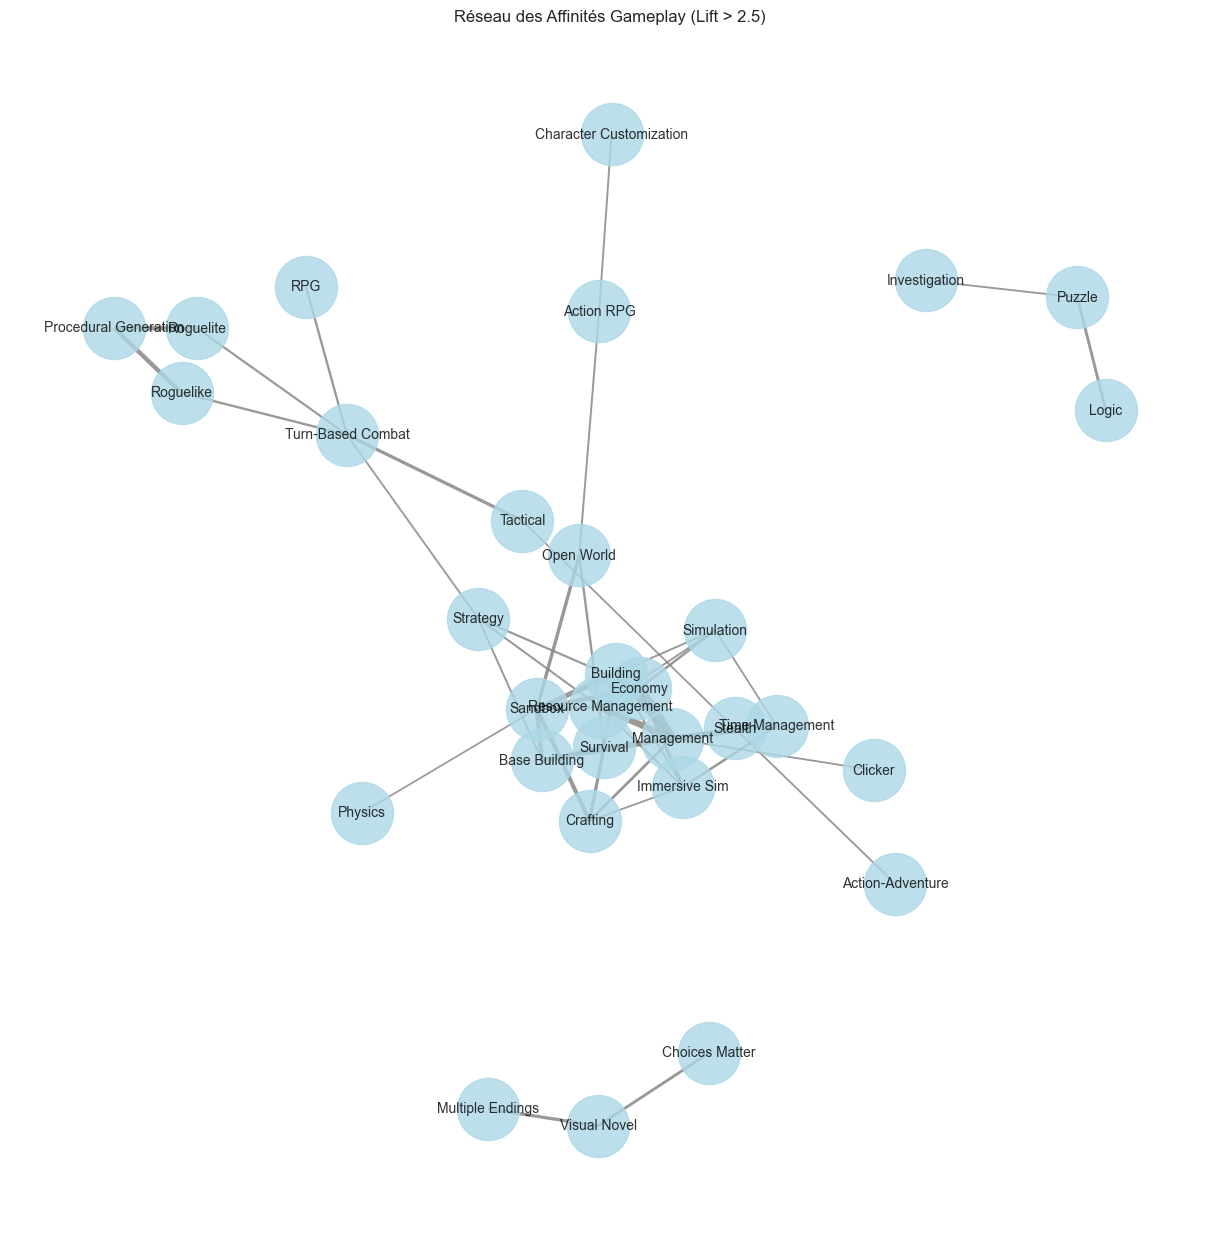

In [18]:
G = nx.Graph()

threshold = 2.5
for g in top_genres:
    for m in top_mechanics:
        weight = lift_matrix.loc[g, m]
        if weight > threshold:
            G.add_edge(g, m, weight=weight)

plt.figure(figsize=(12, 12))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, 
        node_color='lightblue', 
        node_size=2000, 
        font_size=10, 
        width=[G[u][v]['weight']*0.5 for u,v in G.edges()],
        edge_color='gray', 
        alpha=0.8)
plt.title(f"Réseau des Affinités Gameplay (Lift > {threshold})")
plt.show()

Avec un lift de 2.5, certains groupes n'intéragissent pas du tout entre eux, ainsi se forment 3 graphes connexes :
- un relatif aux jeux à puzzle
- un autre relatif au visual novel
- un dernier qui regroupe lui-même plusieurs sous groupes tel que les roguelike, les action rpg, ou encore les jeux de simulation

## 4. Analyse des Motifs Fréquents (FP-Growth)

L'analyse de co-occurrence nous donne des paires. Pour détecter des combinaisons plus complexes (ex: {RPG, Turn-Based} => {Strategy}), nous utilisons l'algorithme **FP-Growth**.

Top 15 Règles d'Association (par Lift) :
                                    antecedents  \
318   frozenset({Strategy, Turn-Based Tactics})   
323            frozenset({Turn-Based Strategy})   
446               frozenset({Action Roguelike})   
443              frozenset({Roguelike, Action})   
451               frozenset({Action Roguelike})   
450              frozenset({Action, Roguelite})   
322             frozenset({Turn-Based Tactics})   
319  frozenset({Strategy, Turn-Based Strategy})   
313            frozenset({Turn-Based Strategy})   
312             frozenset({Turn-Based Tactics})   
315              frozenset({Turn-Based Combat})   
314             frozenset({Turn-Based Tactics})   
198              frozenset({Roguelike, Action})   
203                      frozenset({Roguelite})   
308              frozenset({Turn-Based Combat})   

                                    consequents   support  confidence  \
318            frozenset({Turn-Based Strategy})  0.024695    0.739338

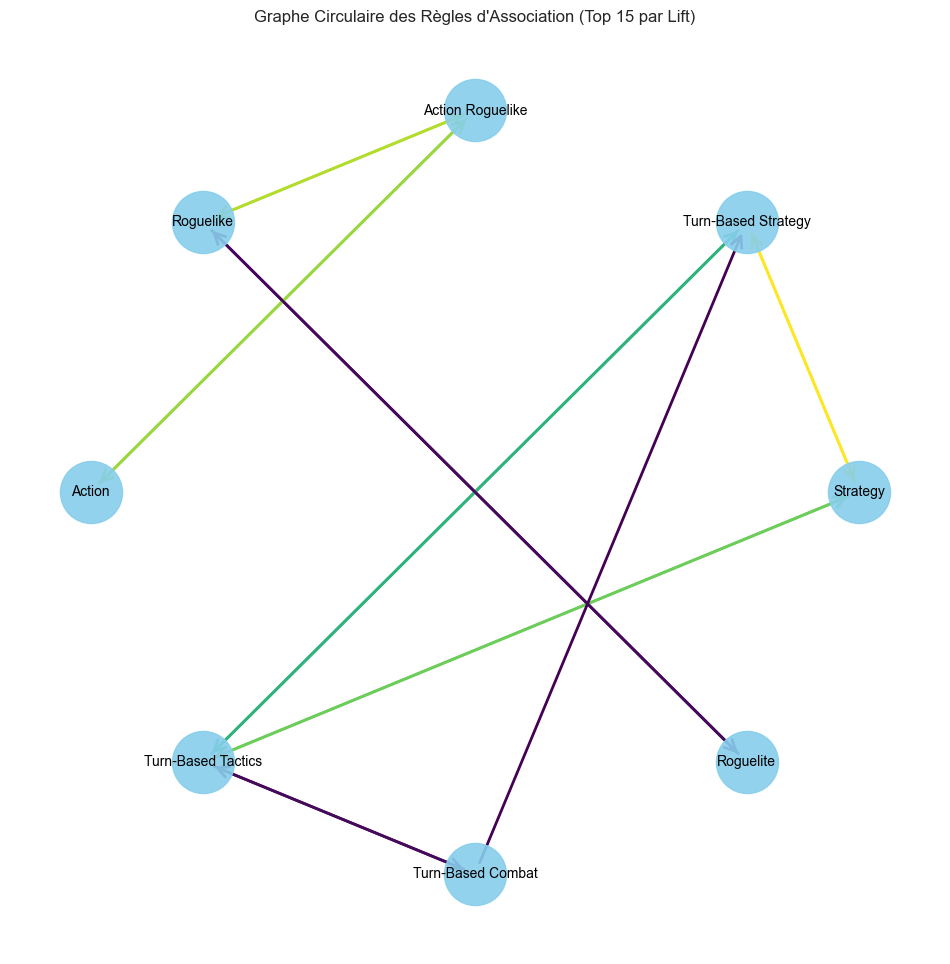

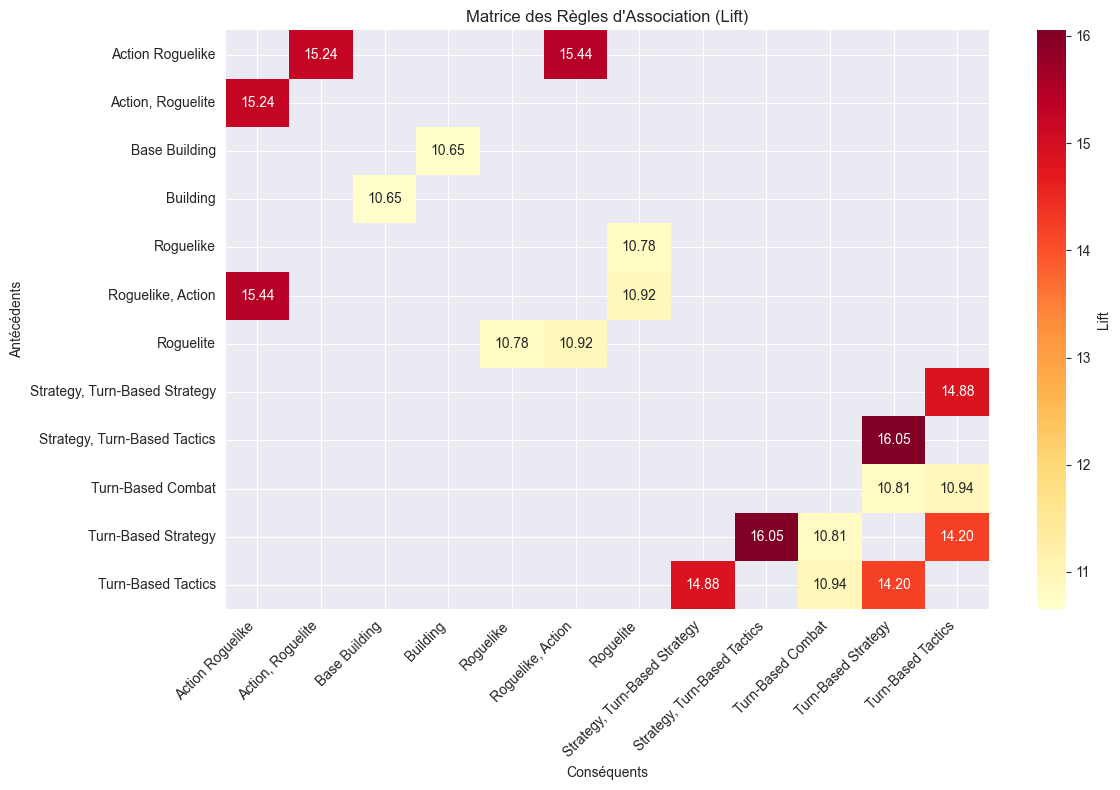

In [19]:
# Tentative d'import de mlxtend pour FP-Growth
try:
    from mlxtend.frequent_patterns import fpgrowth, association_rules
    from mlxtend.preprocessing import TransactionEncoder
    import numpy as np

    # Préparation : Liste de listes de tags
    # On combine Genre et Mechanics
    transactions = []
    for i in df.index:
        row_tags = []
        if pd.notna(df.loc[i, 'Genre']):
            row_tags.extend(df.loc[i, 'Genre'].split(', '))
        if pd.notna(df.loc[i, 'Mechanics']):
            row_tags.extend(df.loc[i, 'Mechanics'].split(', '))
        # Nettoyage
        row_tags = [t for t in row_tags if t and t != 'nan']
        transactions.append(row_tags)

    # Encodage
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)

    # FP-Growth
    # min_support = 0.02 (2% des jeux) pour ne pas avoir trop de bruit
    frequent_itemsets = fpgrowth(df_trans, min_support=0.02, use_colnames=True)

    # Règles d'association
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

    # Tri par Lift
    top_rules = rules.sort_values(by='lift', ascending=False).head(15)

    print("Top 15 Règles d'Association (par Lift) :")
    print(top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

    # --- Visualisation 1 : Graphe Circulaire des Règles ---
    plt.figure(figsize=(12, 12))
    G_rules = nx.DiGraph()

    # On ajoute les règles au graphe
    for idx, row in top_rules.iterrows():
        ant = list(row['antecedents'])[0] # On prend le premier élément pour simplifier l'affichage
        con = list(row['consequents'])[0]
        weight = row['lift']
        G_rules.add_edge(ant, con, weight=weight)

    pos = nx.circular_layout(G_rules)

    # Dessin des nœuds
    nx.draw_networkx_nodes(G_rules, pos, node_size=2000, node_color='skyblue', alpha=0.9)

    # Dessin des arêtes avec couleur selon le poids (Lift)
    edges = G_rules.edges()
    weights = [G_rules[u][v]['weight'] for u,v in edges]

    nx.draw_networkx_edges(G_rules, pos, width=2, edge_color=weights, edge_cmap=plt.cm.viridis,
                           arrowstyle='->', arrowsize=20)

    # Labels
    nx.draw_networkx_labels(G_rules, pos, font_size=10, font_family='sans-serif')

    plt.title("Graphe Circulaire des Règles d'Association (Top 15 par Lift)")
    plt.axis('off')
    plt.show()

    # --- Visualisation 2 : Matrice de Confusion des Règles ---
    # On crée une matrice où x=antecedents, y=consequents, value=lift
    # Pour simplifier, on convertit les frozensets en chaînes
    rules['ant_str'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
    rules['con_str'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))

    # On filtre pour garder les règles les plus significatives pour la matrice (Top 20)
    top_rules_matrix = rules.sort_values(by='lift', ascending=False).head(20)

    pivot_table = top_rules_matrix.pivot(index='ant_str', columns='con_str', values='lift')

    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Lift'})
    plt.title("Matrice des Règles d'Association (Lift)")
    plt.xlabel("Conséquents")
    plt.ylabel("Antécédents")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

except ImportError:
    print("La librairie 'mlxtend' n'est pas installée. Veuillez l'installer avec : pip install mlxtend")

Dans cette nouvelle base de donnée réarrangé, et suite au lift, on obtient des règles d'association forte très différentes de celle obtenue dans notre première analyse.
Ces règles d'association mettent en lumière :
  - la dominance de certains sous genres dans leur genre d'origine, par exemple les Base Building dans les jeux de construction.
  - que certains tags ne sont en réalité que la simple association d'autres tags tel que les Action Roguelike qui sont concrétement l'association d'Action et Roguelike.
  - que certains tags sont des "tags de niche" qui n'ont pas de règles d'association forte, mais qui sont pourtant très cohérents. Par exemple, les jeux de puzzle sont très fortement associés à des mécaniques de réflexion et de logique, mais ces mécaniques ne sont pas associées à d'autres genres, ce qui fait que les règles d'association ne sont pas assez fortes pour être mises en avant.

## Conclusion : Vers une Grammaire du Gameplay

L'analyse de réseau, enrichie par l'algorithme FP-Growth, a transformé une simple liste de tags en une véritable cartographie des structures ludiques de Steam.

**Enseignements majeurs :**

1.  **L'Architecture des Genres (Co-occurrence & Lift)** :
    L'analyse a confirmé que les genres ne sont pas des étiquettes arbitraires mais des systèmes cohérents. Le *Lift* a permis de quantifier la force de ces liens, révélant des "piliers de design" indissociables (ex: *Management* $\leftrightarrow$ *Economy*).

2.  **La Topologie en "Archipel" (Graphes)** :
    La visualisation en réseau a mis en évidence une segmentation nette du marché en trois pôles quasi-indépendants :
    *   Le continent **Action/RPG/Simulation** (dense et hybride).
    *   L'île **Puzzle/Logique** (isolée).
    *   L'île **Narrative/Visual Novel** (autonome).


3.  **Les "Recettes" de Gameplay (FP-Growth)** :
    C'est l'apport crucial de cette étape. Contrairement à la co-occurrence simple (A va avec B), le FP-Growth a révélé des **règles de composition complexes**. Nous avons identifié des chaînes d'implication (ex: *Si un jeu est Roguelike ET Fantasy, ALORS il a une forte probabilité d'être Turn-Based*). Ces règles définissent l'ADN spécifique des sous-genres.

**Transition vers le Clustering :**
Ces résultats prouvent que les tags *Mechanics* et *Genre* possèdent un pouvoir discriminant suffisant pour classifier les jeux. Dans le prochain notebook, nous abandonnerons les étiquettes prédéfinies pour laisser les données "parler" d'elles-mêmes via un **clustering non-supervisé**, afin de découvrir si ces règles forment des familles de jeux que la nomenclature officielle Steam ne couvre pas encore.
